<a href="https://colab.research.google.com/github/aparikh6-droid/temp/blob/main/BUFN400_bhw02_long_term_returns_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### BUFN400 Fall 2026---University of Maryland

# Homework 2: Long-term Returns on Stocks and Bonds

### By Albert S. (Pete) Kyle

There are probably some typos or errors in this homework.  If you find something which seems wrong, please let me know!


$\def \sm {} \renewcommand{\sm}{ {\scriptstyle{\text{*}}}}$
$\def \mm {} \renewcommand{\mm}{{\scriptsize @}}$
$\def \E {} \renewcommand{\E}{\mathrm{E}}$
$\def \e {} \renewcommand{\e}{\mathrm{e}}$
$\def \drm {} \renewcommand{\drm}{\mathrm{\, d}}$
$\def \var {} \renewcommand{\var}{\mathrm{var}}$
$\def \cov {} \renewcommand{\cov}{\mathrm{cov}}$
$\def \corr {} \renewcommand{\corr}{\mathrm{corr}}$
$\def \stdev {} \renewcommand{\stdev}{\mathrm{stdev}}$
$\def \t {} \renewcommand{\t}{^{\mathsf{T}}}$
$\def \comma {} \renewcommand{\comma}{\, , \,}$
$\def \vec {} \renewcommand{\vec}[1]{\mathbf{#1}}$
$\def \skew {} \renewcommand{\skew}{\mathrm{skew}}$
$\def \kurt {} \renewcommand{\kurt}{\mathrm{kurt}}$
$\def \prob {} \renewcommand{\prob}{\textrm{prob}}$
$\def \midx {} \renewcommand{\midx}{\, \mid \,}$



In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Downloading data from WRDS

In this homework, we will be using CRSP data sourced from the WRDS website. Students taking BUFN400 may download data from WRDS but are restricted to downloading using manual queries rather than automated downloads.

Here are the steps to download:

(1) Login to WRDS using the username and password for the course.

(2) For example, to access the CRSP data for this homework, navigate to:

    "Get Data / CRSP / Annual Update / Index - Version 2 (CIZ) / Monthly History Record".
    
    You should be on a query page.

(3) Download the data by filling out the query information. You should choose (a) as long a time series as possible (typically beginning 1925-12 and ending 2025-12), (b) either monthly or daily frequency as needed, (c) all query variables (by clicking on the box checked "All" to download as much data as possible since this dataset is small), (d) either csv or gz (use gz compression if you need to save space on disk or make data transfer faster), (e) the first date format "YYYY-MM-DD" (since this is a good standard format).

Save your data under a convenient name.

**THIS HOMEWORK IS QUITE LONG.  YOU SHOULD SPEND A REASONABLE AMOUNT OF TIME ON IT. IF IT IS ABSOLUTELY TOO LONG TO FINISH ON TIME, PLEASE SKIP THE OPTIONAL OR EXTRA CREDIT QUESTIONS.**


## Problem 1


#### Problem 1.1

1. Under "CRSP / Annual Update / Index - Version 2 (CIZ) / Monthly History Record", download the entire time period, monthly data, and all variables.  

    * Show the number of rows and columns, the names of the columns, and the first few rows of data.



In [14]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import datetime
import timeit
import os
import sys

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 100)

dir_path = r"/content/drive/MyDrive/BUFN400/"
file_name = "BH2StockData.csv"

file_path = os.path.join(dir_path, file_name)

df = pd.read_csv(file_path)

In [15]:
print("Rows: " + str(df.shape[0]))
print("Columns: " + str(df.shape[1]))
print("Columns: " + str(df.columns))
df.head()

Rows: 10252
Columns: 10
Columns: Index(['INDNO', 'YYYYMM', 'IndNm', 'MthCalDt', 'MthTotRet', 'MthTotInd', 'MthPrcRet', 'MthPrcInd',
       'MthIncRet', 'MthIncInd'],
      dtype='object')


,INDNO,YYYYMM,IndNm,MthCalDt,MthTotRet,MthTotInd,MthPrcRet,MthPrcInd,MthIncRet,MthIncInd
0,1000708,192512,CRSP 30-Day Bill Returns,1925-12-31,NaN,38.91,NaN,NaN,NaN,NaN
1,1000707,192512,CRSP 90-Day Bill Returns,1925-12-31,NaN,34.84,NaN,NaN,NaN,NaN
2,1000511,192512,CRSP Equal-Weighted Portfolios of the S&P 500 ...,1925-12-31,NaN,0.88,NaN,6.66,NaN,13.35
3,1000356,192512,CRSP NYSE/NYSEMKT/Nasdaq Cap-Based Portfolio M...,1925-12-31,NaN,1.00,NaN,1.00,NaN,1.00
4,1000510,192512,CRSP Value-Weighted Portfolios of the S&P 500 ...,1925-12-31,NaN,1.38,NaN,11.93,NaN,11.63


#### Problem 1.2

2. This dataset contains returns data on numerous CRSP-defined portfolios of equities, as well as data on bond returns and the Consumer Price Index. The data is stacked, with one row for each portfolio and month.

    * Verify that the two columns 'INDNO' and 'YYYYMM' define a unique key for the rows.

    * Verify that 'IndNm' is equivalent to 'INDNO', and 'MthCalDt' is equivalent to 'YYYYMM'. (Here, "equivalent" means a one-to-one relationship between values.)

    * In your opinion, which key is better ('INDNO', 'YYYYMM') or ('IndNm', 'MthCalDt')?  Why?


In [16]:
print(df.duplicated(['INDNO', 'YYYYMM']).sum())

print(df.groupby('IndNm')['INDNO'].nunique().max())
print(df.groupby('INDNO')['IndNm'].nunique().max())
print(df.groupby('YYYYMM')['MthCalDt'].nunique().max())
print(df.groupby('MthCalDt')['YYYYMM'].nunique().max())

0
1
1
1
1


The 0 proves there are no duplicates. The 1s show that the labels are equivalent.

In my opinion, INDNO and YYYYMM are better as INDNO is numerical which makes it easier to use when programming and YYYYMM makes it easy to read as the reporting day is always the last day of the month anyways.

#### Problem 1.3

3. We will not need all of the data for this homework. We will be specifically interested in the following columns:

    `cols = ['MthCalDt', 'MthTotRet', 'MthTotInd', 'MthPrcRet', 'MthPrcInd', 'MthIncRet', 'MthIncInd']`

    We will also be interested in the nine series with the following names, which are a subset of the names in 'IndNm':

    `portfolio_names = ['Consumer Price Index', 'CRSP 30-Day Bill Returns', 'CRSP 90-Day Bill Returns',
    'CRSP 2-Year Bond Returns', 'CRSP 10-Year Bond Returns', 'CRSP 30-Year Bond Returns',
    'CRSP NYSE/NYSEMKT/Nasdaq Cap-Based Portfolio Market', 'CRSP Value-Weighted Portfolios of the S&P 500 Universe',
    'CRSP Equal-Weighted Portfolios of the S&P 500 Universe', ]`

    Using google, AI, or CRSP documentation on WRDS, figure out what  the portfolios and columns we are interested in mean.


In [17]:
portfolio_names = ['Consumer Price Index','CRSP 30-Day Bill Returns','CRSP 90-Day Bill Returns','CRSP 2-Year Bond Returns','CRSP 10-Year Bond Returns','CRSP 30-Year Bond Returns','CRSP NYSE/NYSEMKT/Nasdaq Cap-Based Portfolio Market','CRSP Value-Weighted Portfolios of the S&P 500 Universe','CRSP Equal-Weighted Portfolios of the S&P 500 Universe']
cols = ['MthCalDt', 'MthTotRet', 'MthTotInd', 'MthPrcRet', 'MthPrcInd', 'MthIncRet', 'MthIncInd']

The portfolios track many different indicies and ETFs. CPI is the general cost of a basket of goods over time. 30 and 90 day Bill returns tracks the returns of investing in T-Bills. 2, 10, and 30 year tracks the returns of investing in T-Bonds. The NYSE/SYSEMKT/Nasdaq Cap-Based Portfolio tracks all the stocks on the major US stock exchanges weighted by market cap. Value weighted tracks the S&P 500 based on market cap. Equal weighted tracks the S&P 500, however each company has an equal share of the portfolio.

MthcalDt is the Month and Year. MthTotRet is the total percentage return during that month assuming everything is reinvested. MthTotInd tells you how much money you would have if you started with 1 or 100 (depending on what was used in the calculation) at the start of the portfolio. MthPrcRet is monthly price return excluding distributions. MthPrcInd is similar to MthTotInd, however it does not account for distributions, just the gains made on pure original capital. MthIncRet is the gain from solely distributions, not counting the original capital, just what came from it. MthIncInd is similar to MthTotInd, however it does not take into account growth of the original capital, just the gain from distributions.


#### Problem 1.4

4.  The column 'MthTotInd' represents how an investment grows by being invested in a given portfolio, such as 'CRSP Value-Weighted Portfolios of the S&P 500 Universe', which mimics an investment in the SP 500. Draw two plots of 'MnthTotInd' with nine series on each plot showing how a 1 dollar investment at the beginning of the series grows month by month over the entire time period. On each plot, there should be multiple stock series and multiple bond series.

    * The first plot should consider "nominal" returns, not adjusted for inflation.  
    
    * The second plot should show real returns, deflated by the consumer price index.  
    
    * Explain why it is or is not more financially and economically meaningful to plot the y-axis on a log scale as opposed to an un-logged scale.

* Hint: To make the data easier to work with, you might consider **unstacking** the data so that the portfolios referred to by 'INDNO' or equivalently 'IndNm' become names of columns rather than values of 'INDNO' or 'IndNm' in rows. For example, if `df` is the the dataframe containing the Monthly Historical Record data, you might create a dictionary of dataframes `ddf` like this:

    ```python
    ddf = {}
    for c in df.columns:
        ddf[c] = df[c].unstack('IndNm')
    ```

    Each column in the original dataframe `df` now becomes its own dataframe `ddf[c]`.  The rows of `ddf[c]` are data corresponding to various dates and the columns are identifiers of portfolios. Taking this approach, you will be plotting a subset of the columns of dataframe `ddf['MthTotInd']`.


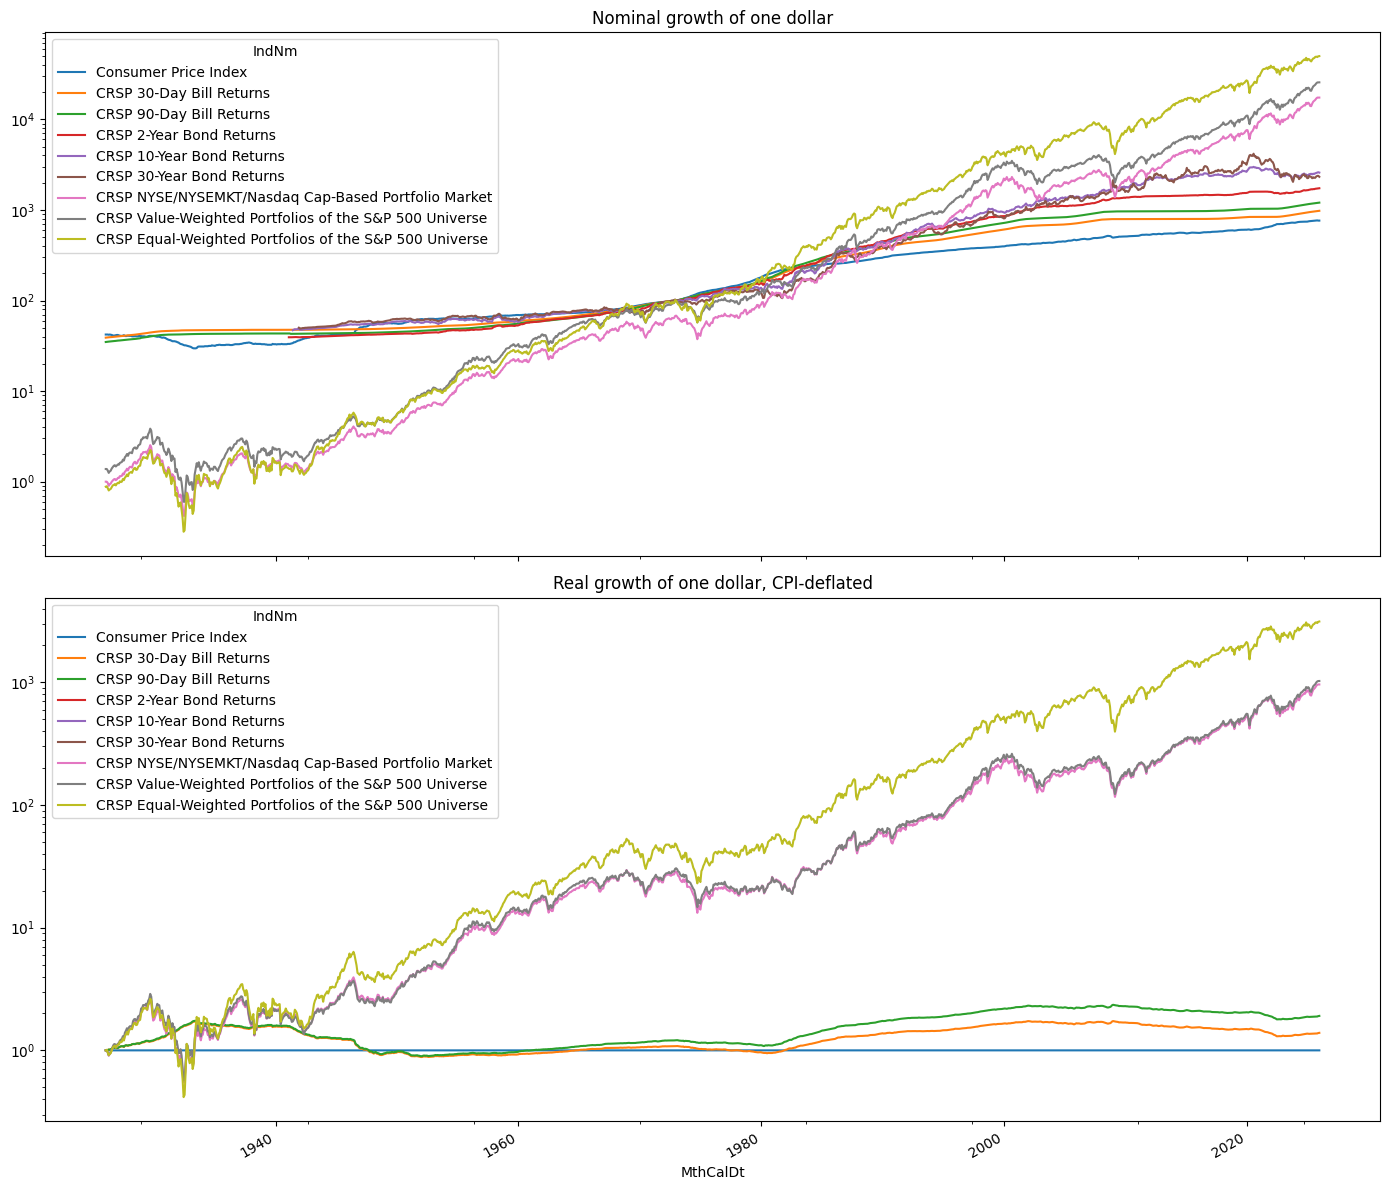

In [18]:
df['MthCalDt'] = pd.to_datetime(df['MthCalDt'])

ddf = {}
for column_name in df.columns:
    ddf[column_name] = df.pivot(index='MthCalDt', columns='IndNm', values=column_name).sort_index()

nominal = ddf['MthTotInd'][portfolio_names]
real = nominal.div(nominal['Consumer Price Index'], axis=0)
real = real.div(real.iloc[0])
fig, ax = plt.subplots(2,1,figsize=(14,12),sharex=True)
nominal.plot(ax=ax[0], logy=True, title='Nominal growth of one dollar')
real.plot(ax=ax[1], logy=True, title='Real growth of one dollar, CPI-deflated')
plt.tight_layout()


It makes more sense to use a log scale so that you can accurately compare changes in percent instead of actual dollar values. A 100% increase for one dollare vs 100 is the same percent, but a very different dollar value and would not be a good way to track what kind of returns are being made.


#### Problem 1.5

5. Since the columns of `ddf['MthTotInd']` represent how portfolio grows over time as a result of returns on the portfolio, it should be possible to construct series equivalent to the columns of `ddf['MthTotInd']` from the columns of `ddf['MthTotRet']`.

    * Construct a dataframe equivalent to `ddf['MthTotInd']` (up to a theoretically constant factor) from `ddf['MthTotRet']`.

    * Plot the ratios of the equivalent series. Can you explain why the theoretically equivalent series are not exactly equivalent? (As nearly as I can tell, this question has a weird answer.)

    * Hint: Keep in mind that cumulative returns are multiplicative: If $r_0$ and $r_1$ are returns for two adjacent, nonoverlappying periods, as in 'MthTotRet', then $(1+r_0) \sm (1+r_1) -1$ is the return over two periods.  In terms of "gross returns" $R := 1+r$, we can write the return over two periods as $R_0 \sm R_1$. Numpy and pandas have functions `cumsum` and `cumprod`. You should use `cumprod` to calculate cumulative returns without writing a slow Python loop!

    * Hint: Some of the series have missing data. You might consider setting missing returns to zero so that the cumulative return factor shows up as a flat line when the series is not defined.


IndNm,Consumer Price Index,CRSP 30-Day Bill Returns,CRSP 90-Day Bill Returns,CRSP 2-Year Bond Returns,CRSP 10-Year Bond Returns,CRSP 30-Year Bond Returns,CRSP NYSE/NYSEMKT/Nasdaq Cap-Based Portfolio Market,CRSP Value-Weighted Portfolios of the S&P 500 Universe,CRSP Equal-Weighted Portfolios of the S&P 500 Universe
count,1201.000000,1201.000000,1201.000000,1020.000000,1016.000000,1010.000000,1201.000000,1201.000000,1201.000000
mean,42.117819,38.910598,34.836882,39.545944,46.975439,50.270927,0.999996,1.379923,0.884592
std,0.001803,0.001522,0.001509,0.001477,0.001384,0.001445,0.001025,0.001025,0.001075
min,42.111326,38.906558,34.832776,39.540991,46.970721,50.266009,0.994930,1.374596,0.876177
25%,42.117198,38.910056,34.836437,39.545653,46.975132,50.270570,0.999958,1.379914,0.884564
50%,42.117693,38.910606,34.836933,39.545998,46.975439,50.270895,1.000004,1.379947,0.884584
75%,42.118334,38.910945,34.837314,39.546211,46.975750,50.271272,1.000013,1.379963,0.884589
max,42.123747,38.915276,34.841586,39.550948,46.980111,50.275971,1.009813,1.388165,0.895804


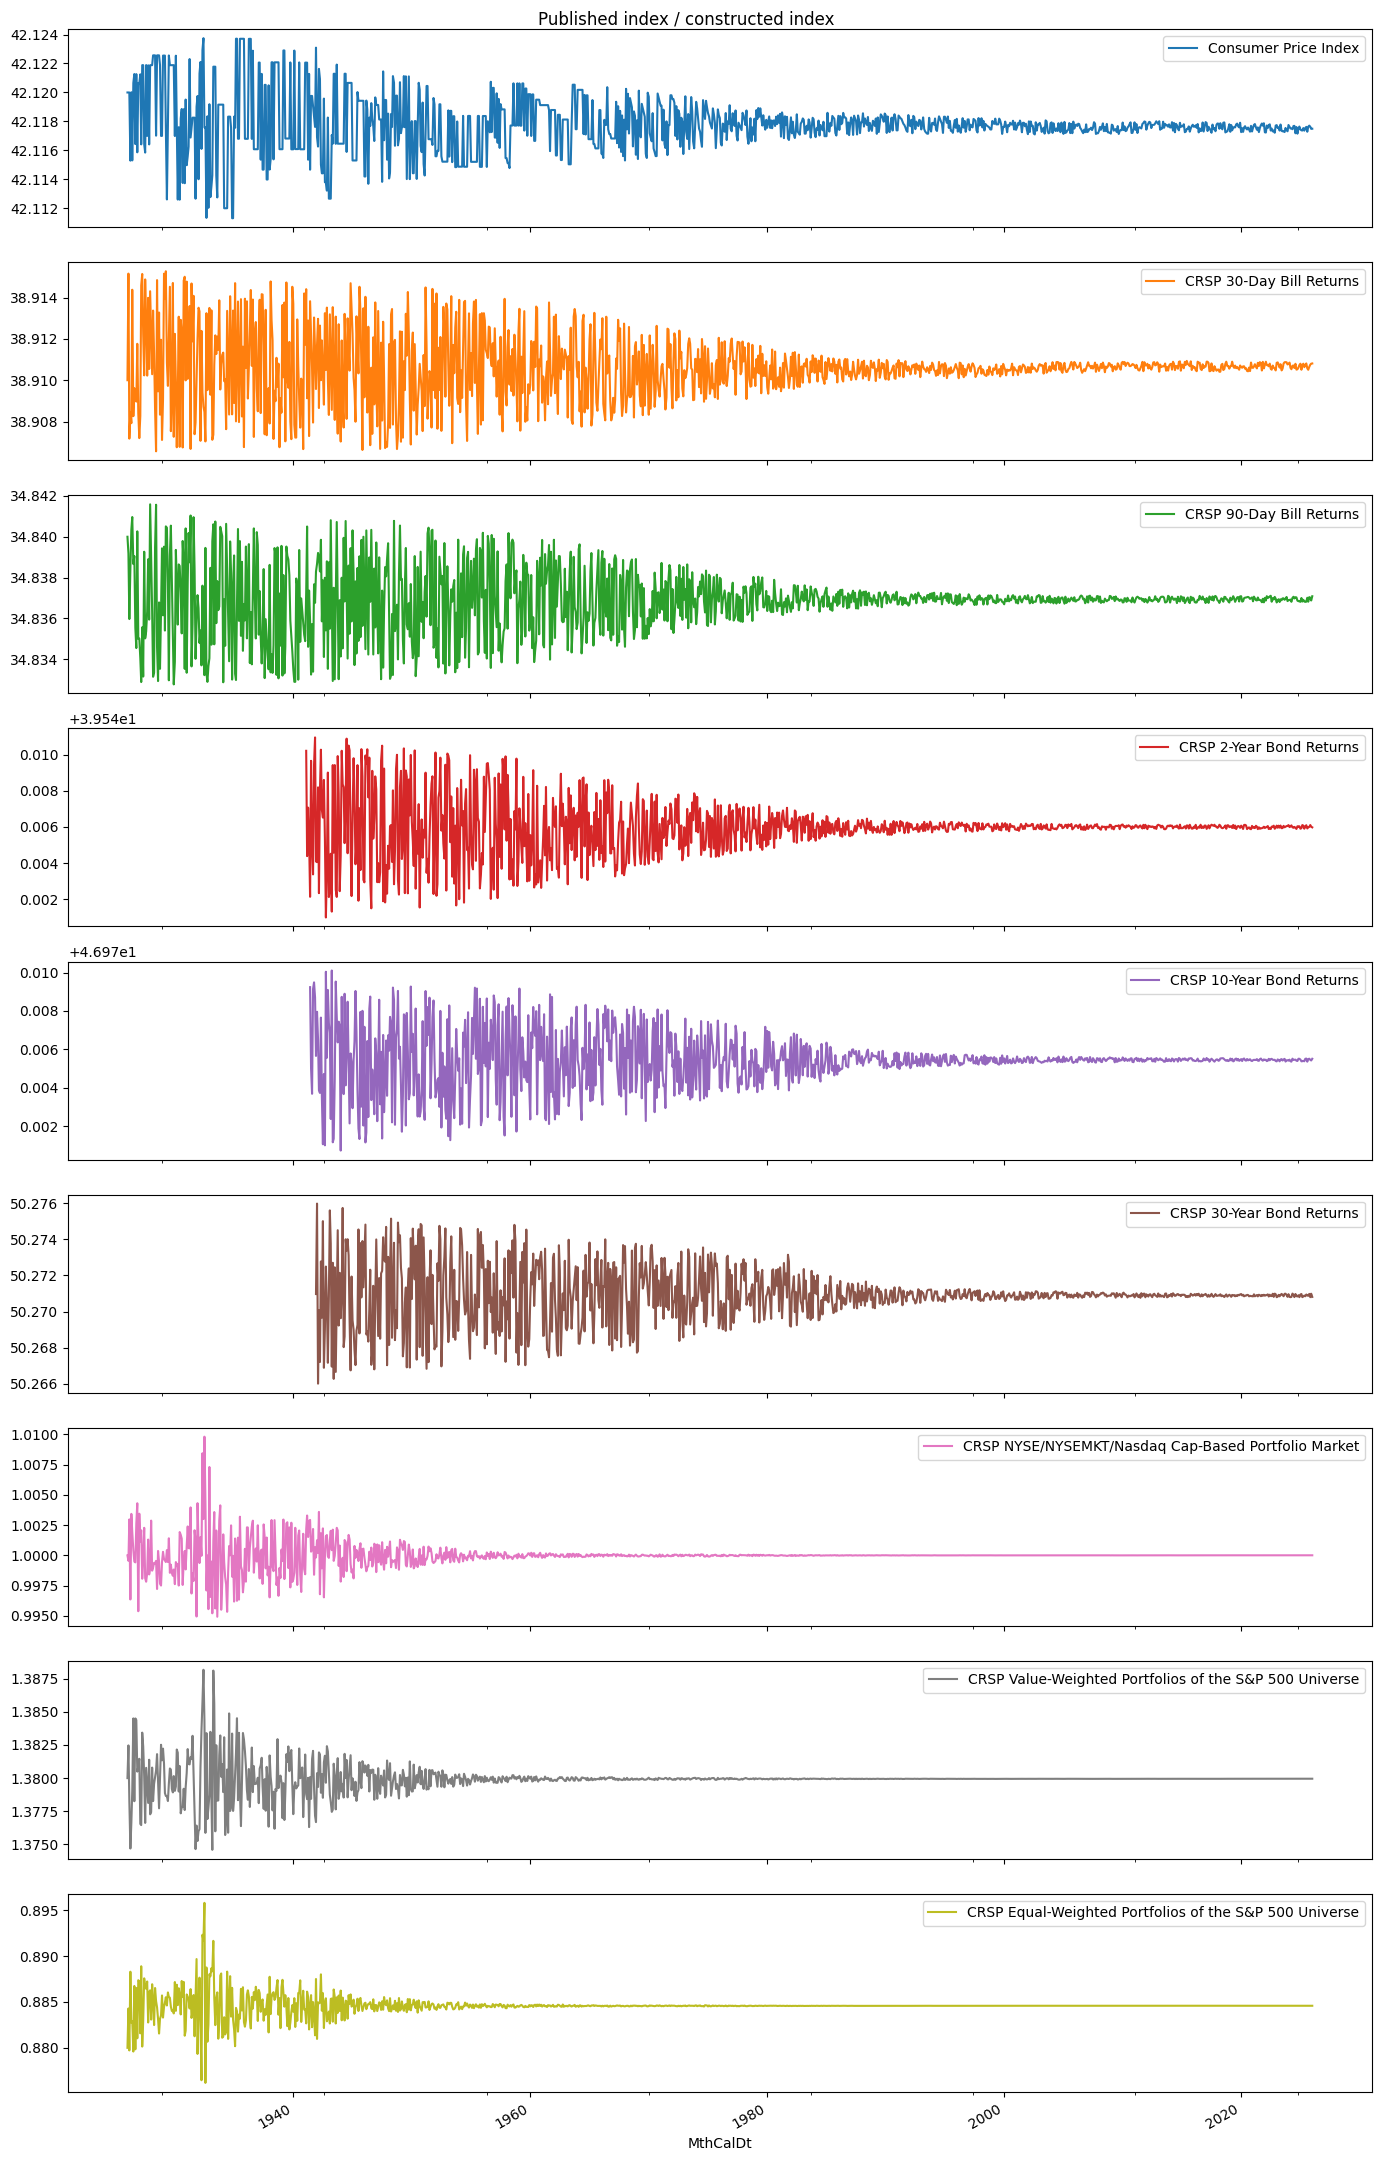

In [19]:
constructed = (1 + ddf['MthTotRet'][portfolio_names].fillna(0)).cumprod()
ratios = ddf['MthTotInd'][portfolio_names] / constructed; display(ratios.describe())
ratios.plot(subplots=True, figsize=(14,22), title='Published index / constructed index')
plt.tight_layout()

Some of the numbers might be rounded which could cause errors when doing a final computation, especially over long periods of time. Also, some fields are missing which could cause other inconsistencies.

#### Problem 1.6

6. Now consider the three return-related variables 'MthTotRet', 'MthPrcRet', and 'MthIncRet'. Using CRSP documentation, google, or AI, figure out how these three series are related. Theoretically, 'MthTotRet' should be approximately the sum of the other two. Suppose that a taxable investor's "income", reported by 'MthIncRet', is taxed at rates 0 percent, 40 percent or 70 percent.

    * Present plots showing how one after-tax dollar grows over 100 years for the portfolio 'CRSP Value-Weighted Portfolios of the S&P 500 Universe' and 'CRSP 30-Day Bill Returns'. For 'CRSP 30-Day Bill Returns' and other bond returns, 'MthPrcRet' and 'MthIncRet' are all missing; therefore for 30-Day Bill returns, assume that the entire monthly return is taxed (as interest income).

        Note: Perhaps CRSP did not populate 'MthPrcRet' and 'MthIncRet' for the bond returns because the division between income and capital gains depends on the coupons of the bonds, and there are different coupons outstanding at different times.

    * If the government invested all of its tax revenue in the same asset at the time the revenue is collected (pretend monthly), how much would be government have at the end of 100 years?

    Hint: A quick way to calculate this is to note that the government will have all of the total untaxed return that the taxable investor did not receive.

    * What percentage of the present value of the investment go to the taxable investor and what percentage to the government? (The answer to this question is related to the effects of what taxpayers and economists call "double taxation.")


In [20]:
equity = ddf['MthTotRet']['CRSP Value-Weighted Portfolios of the S&P 500 Universe']
price = ddf['MthPrcRet']['CRSP Value-Weighted Portfolios of the S&P 500 Universe']
income = ddf['MthIncRet']['CRSP Value-Weighted Portfolios of the S&P 500 Universe']
bill = ddf['MthTotRet']['CRSP 30-Day Bill Returns']
tax_summary = []
for label, tot, pr, inc in [('S&P 500', equity, price, income), ('30-Day Bills', bill, None, None)]:
    untaxed = (1 + tot.fillna(0)).cumprod();
    for t in [0,.40,.70]:
        after = (1 - t) * tot if pr is None else pr + (1 - t) * inc
        investor = (1 + after.fillna(0)).cumprod()
        government = untaxed - investor
        end = investor.index[-1]
        tax_summary.append([label, t, investor.loc[end], government.loc[end], investor.loc[end] / untaxed.loc[end], government.loc[end] / untaxed.loc[end]])
    display(pd.DataFrame(tax_summary, columns=['Asset','Tax rate','Investor wealth','Government wealth','Investor share','Government share']))


,Asset,Tax rate,Investor wealth,Government wealth,Investor share,Government share
0,S&P 500,0.0,18572.049549,-0.380128,1.000020,-0.000020
1,S&P 500,0.4,4332.359808,14239.309613,0.233278,0.766722
2,S&P 500,0.7,1451.271452,17120.397969,0.078144,0.921856


,Asset,Tax rate,Investor wealth,Government wealth,Investor share,Government share
0,S&P 500,0.0,18572.049549,-0.380128,1.000020,-0.000020
1,S&P 500,0.4,4332.359808,14239.309613,0.233278,0.766722
2,S&P 500,0.7,1451.271452,17120.397969,0.078144,0.921856
3,30-Day Bills,0.0,25.143398,0.000000,1.000000,0.000000
4,30-Day Bills,0.4,6.935754,18.207644,0.275848,0.724152
5,30-Day Bills,0.7,2.635497,22.507901,0.104819,0.895181



#### Problem 1.7 (Extra Credit)

7. For each date from ten years after the start of the series until the last date in the dataset, make two plots of the cumulative return on `portfolio_names` over the previous 1, 3, and 10 years. The first plot should be nominal returns and the last plot real returns.  Which were the best and worst periods of 1, 3, and 10 years for equity returns, bond returns, and inflation?

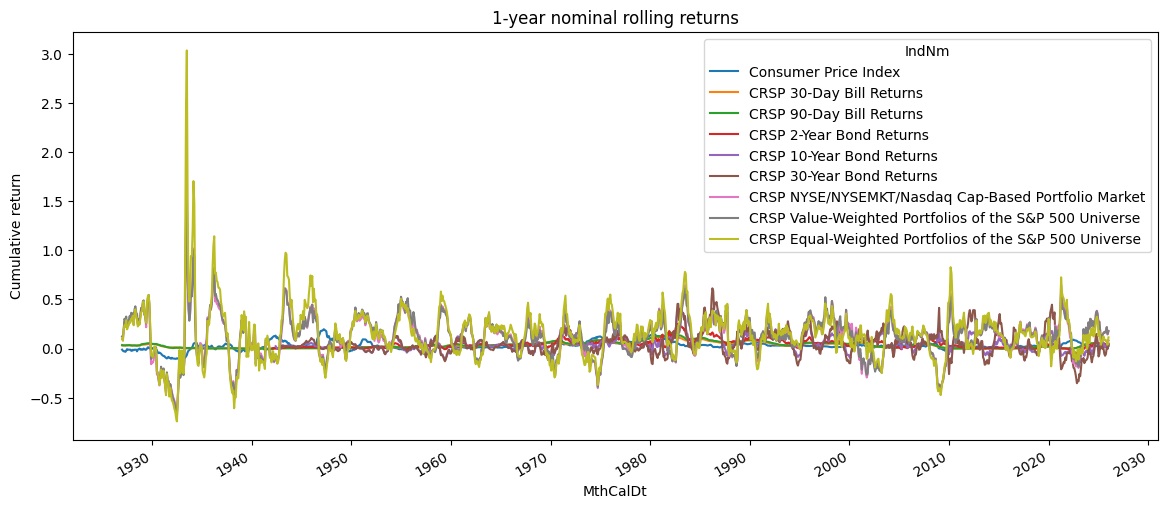

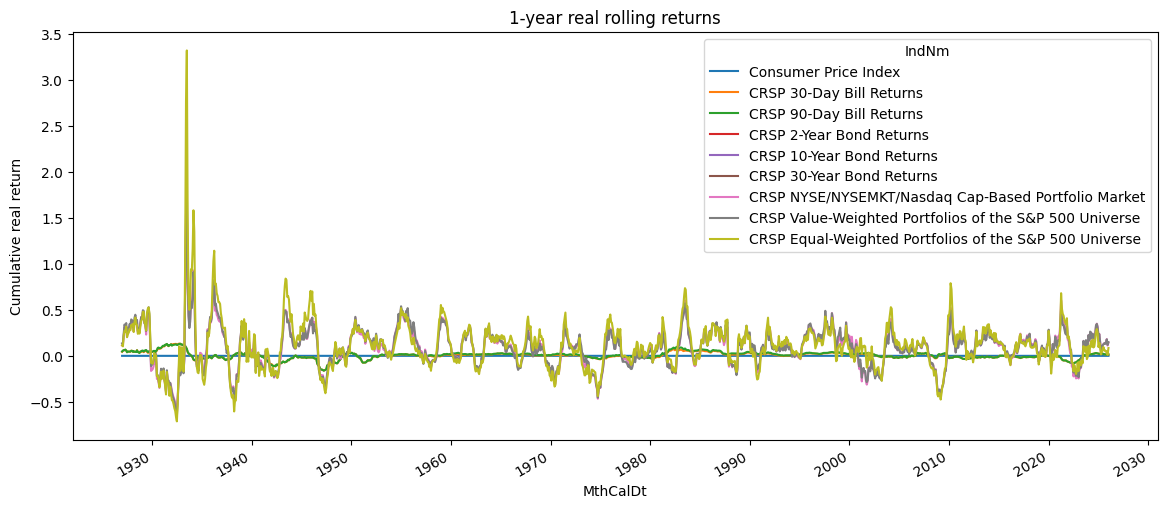

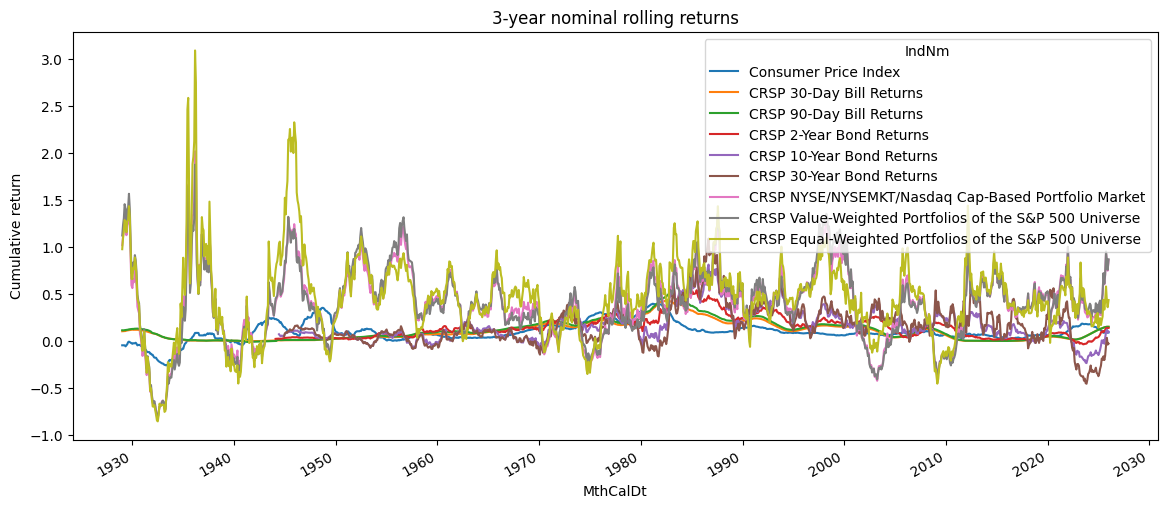

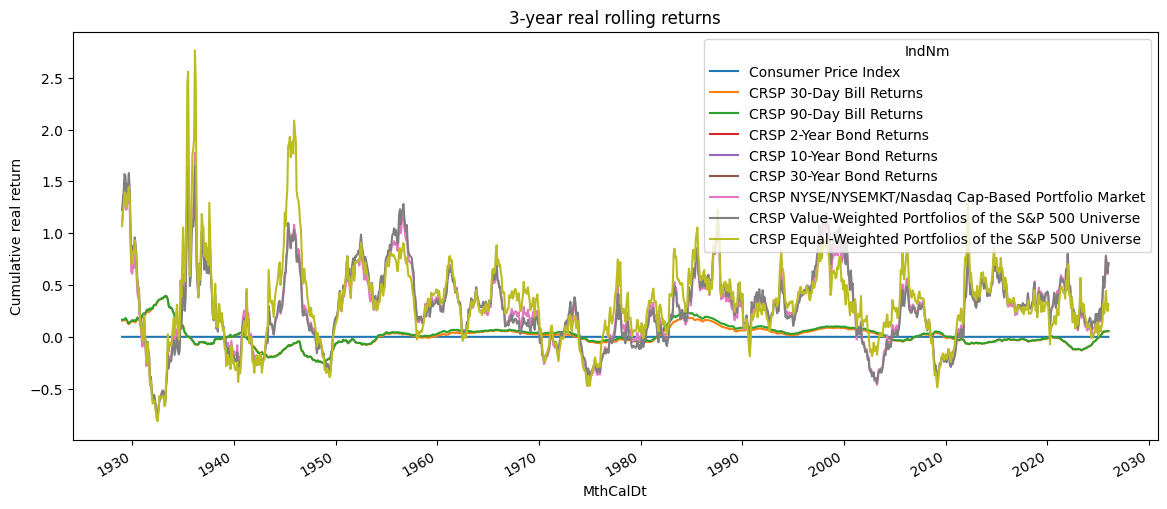

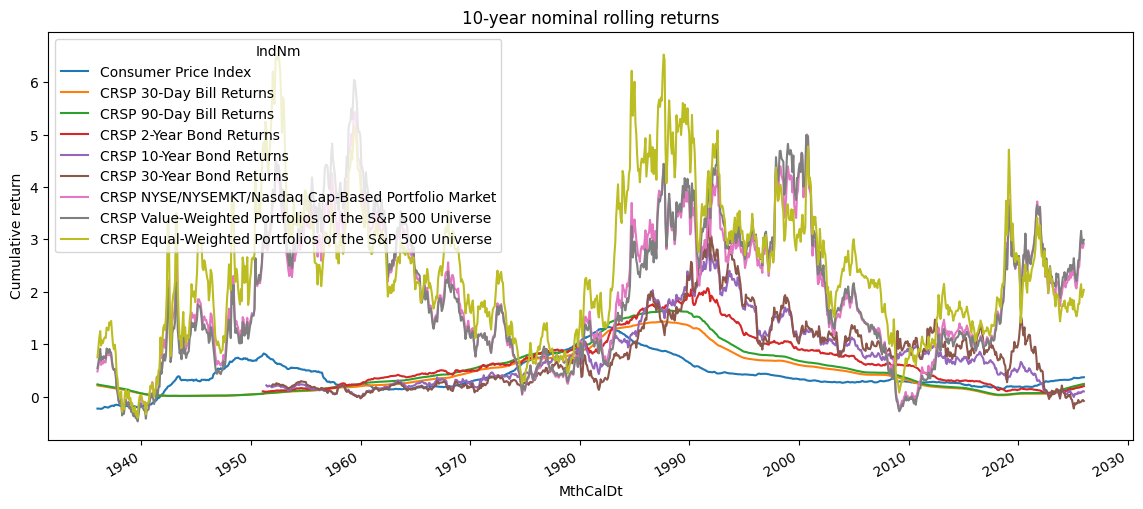

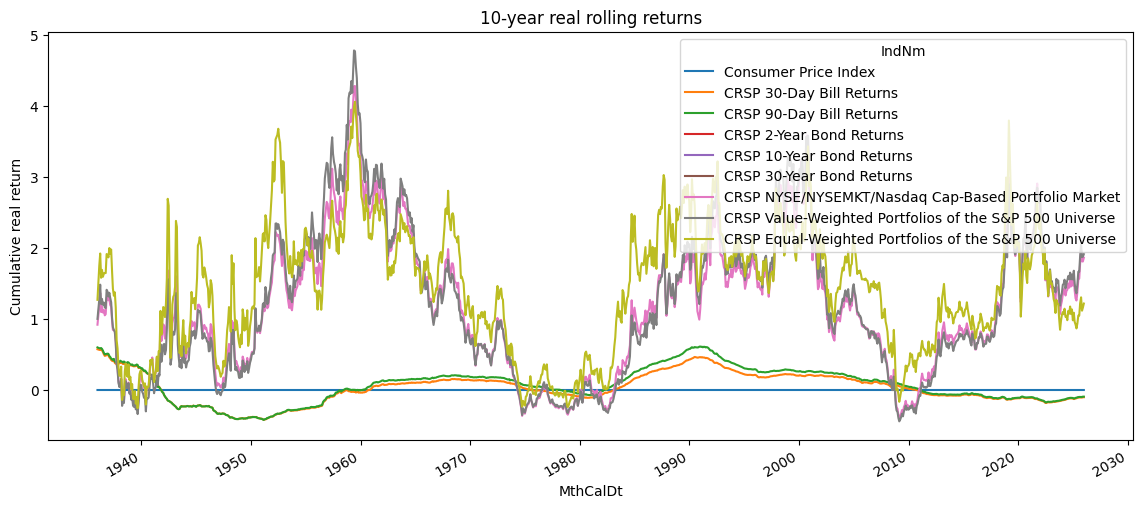

In [21]:
import matplotlib.dates as mdates

for years in [1, 3, 10]:
    months = 12 * years
    rolling_nominal = nominal / nominal.shift(months) - 1
    rolling_real = real / real.shift(months) - 1

    rolling_nominal.plot(figsize=(14, 6), title=f'{years}-year nominal rolling returns')
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.YearLocator(10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.ylabel('Cumulative return')
    plt.show()

    rolling_real.plot(figsize=(14, 6), title=f'{years}-year real rolling returns')
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.YearLocator(10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.ylabel('Cumulative real return')
    plt.show()



Equity:
- Best
  - 1yr: ~1932-1933
  - 3yr: ~1933-1936
  - 10yr: ~1942-1952
- Worst
  - 1yr: ~1931-1932
  - 3yr: ~1929-1932
  - 10yr: ~1929-1939

Bonds:
- Best
  - 1yr: ~1985-1986
  - 3yr: ~1983-1986
  - 10yr: ~1981-1991
- Worst
  - 1yr: ~2021-2022
  - 3yr: ~2020-2023
  - 10yr: ~2015-2025

Inflation:
- Best
  - 1yr: ~1946-1947
  - 3yr: ~1978-1981
  - 10yr: ~1972-1982
- Worst
  - 1yr: ~1931-1932
  - 3yr: ~1930-1933
  - 10yr: ~1926-1936

## Problem 2


#### Problem 2.1

1. The difference between the return on a stock portfolio, say $r_e = $ 'CRSP Value-Weighted Portfolios of the S&P 500 Universe', and a safe asset, $r_f = $ 'CRSP 30-Day Bill Returns', is referred to as an "excess return".  Calculate the monthly difference between returns on stocks $r_e$ and returns on T-Bills $r_f$ in three different ways:

    * Calculate the mean of $r_e - r_f$ over all months. This is called the sample **mean excess return**. This is an example of an **arithmetic mean**.

    * Calculate the product of the ratios of all gross returns $(1 + r_e) / (1 + r_f)$ over all months, then take the $N$ th root where $N$ is the number of months. The result is a **geometric mean**, which is different from an **arithmetic mean**. Now subtract 1 to make the result  comparable to the previous result. Call this the sample relative **internal rates of return**.

    *  Calculate the mean of the log return difference $\log(1 + r_e) - \log(1 + r_f)$.


In [22]:
re = ddf['MthTotRet']['CRSP Value-Weighted Portfolios of the S&P 500 Universe']
rf = ddf['MthTotRet']['CRSP 30-Day Bill Returns']
valid = pd.concat([re, rf], axis=1).dropna()
re, rf = valid.iloc[:, 0], valid.iloc[:, 1]
mth_excess_return = re - rf
mean_excess_return = mth_excess_return.mean()
gross_relative_returns = (1 + re) / (1 + rf)
relative_irr = gross_relative_returns.prod() ** (1 / len(valid)) - 1
log_excess_return = np.log1p(re) - np.log1p(rf)
mean_log_excess_return = log_excess_return.mean()

print('Sample mean excess return:', mean_excess_return)
print('Sample relative internal rate of return:', relative_irr)
print('Mean log excess return:', mean_log_excess_return)



Sample mean excess return: 0.006962542499999999
Sample relative internal rate of return: 0.00551917248173317
Mean log excess return: 0.005503997658663987



#### Problem 2.2

2. You should find that the result from first calculation is different from the result from the second, but the results from the second and third calculations are similar.

    * What is the difference between the first two calculations?

    * What is the difference between the second and third calculations?


The difference between the first two calculations is because the mean excess return ignores compounding and volatility drag. The relative irr incorporates compounding gains and losses, this makes volatility drag on the price and lowers it compared to the mean excess return.

The difference between the second and third is that one is a simple return vs the other is continuously compounded. They are still close as the monthly returns are relatively small.


#### Problem 2.3

3. Calculate the monthly standard deviation of the excess returns $r_e - r_f$. Calculate the monthly standard deviation of "log excess returns" $\log(1+r_e) - \log(1+r_f)$.

    * How similar are these two standard deviations?
    
    * Annualize the monthly standard deviations by multiplying by $\sqrt{12}$. Explain why you multiply by $\sqrt{12}$ and not by 12. Compare with how to annualize the monthly means and variances?


In [23]:
print('Monthly simple/log SD:', mth_excess_return.std(), log_excess_return.std())
print('Annualized simple/log SD:', np.sqrt(12) * mth_excess_return.std(), np.sqrt(12) * log_excess_return.std())

Monthly simple/log SD: 0.053787365728640714 0.05356539609034588
Annualized simple/log SD: 0.18632490049458938 0.1855559751120607


Simple and log standard deviations are normally pretty similar and these are no different. You multiply by root 12  because standard deviate is the square root of variance and when you want to go from monthly to yearly, you have to multiply by 12.


#### Problem 2.4

4. If log returns are normally distributed, the difference between the arithmetic mean and the log return difference (or geometric mean) should theoretically be approximately one-half the return variance.

    * Is this approximately true for the calculations in question 2.1?


In [24]:
print('Mean minus geometric:', mean_excess_return - relative_irr)
print('Half log-excess variance:', 0.5 * log_excess_return.var())

Mean minus geometric: 0.0014433700182668293
Half log-excess variance: 0.0014346258291578209


It seems like it is true.


#### Problem 2.5

5. Explain in one or two sentences why the returns on stocks should be expected to be different from the returns on T-Bills or bonds.




Stocks are based on what the market is willing to pay for them and because of this, they can go to zero if a company tanks. A bond promises a return on investment which makes it safer, causing it to have less upside potential.

## Problem 3  (Optional, Extra Credit)


#### Problem 3.1

1. Consider the return columns corresponding to `portfolio_names`.

    * Display the results of the function `df.describe()`, where `df` loops through each of the portfolios `ddf[c]` for `c` in `portfolio_names` and the columns are restricted to `cols` from Problem 1.
    
    * Construct your own dataframe from scratch (without using `df.describe()`) showing various summary statistics describing the same series, including mean, variance, standard deviation, max, min, number of missing observations, and number of returns equal to exactly zero. For each `df[c]`, place the statistics in a dataframe where the rows are the names of the relevant variables and the columns are the names of the various statistics (the opposite of `df.describe()`).
    
    * Are your results consistent with the results of `df.describe()`?


#### Problem 3.2

2. For the return series 'MthTotRet', calculate an "annualized historical mean return" by multiplying the monthly mean return by 12 (months per year). Does this number (a scalar) appear to be financially reasonable?


#### Problem 3.3

3. Review basic statistical concepts, like mean, variance, standard deviation, and covariance. Recall that the standard deviation is the square root of the variance.

    * Why do many researchers and practitioners prefer to look at numbers which are standard deviations rather than numbers which are variances?


#### Problem 3.4

4. If $N$ is the number of observations in a series $x$, the sample standard deviation is sometimes calculated by  dividing by $N$ and sometimes by dividing by $N-1$, like `np.sqrt(np.sum((x - x.mean())**2) / N)` or `np.sqrt(np.sum((x - x.mean())**2) / (N-1))`.

    * Which version does pandas (`df.std()` for dataframe `df`) or numpy (`x.std()` for array `x`) use by default? (Hint: The pandas standard deviation can be compared with the numpy standard deviation by using the pandas function `to_numpy`.)


#### Problem 3.5

5. Which version of standard deviation (with $N$ or $N-1$) do you think is most appropriate for a time series of returns? (This is a non-trivial question whose answer depends on combining finance thinking with statistical definitions.)


#### Problem 3.6

6. The standard deviation of returns is often called **volatility**.

    * Calculate an "annualized historical return volatility" by multiplying the monthly sample volatility (a scalar) by $\sqrt{12}$.
    
    Multiplying by $\sqrt{12}$ is appropriate when monthly returns are approximately uncorrelated.



#### Problem 3.7:

7. Check whether returns are indeed approximately uncorrelated by calculating the **autocorrelation** of the various return series. (Hint: Use the pandas `autocorr` function.)


#### Problem 3.8

8. Finance researchers and practitioners often work with **log returns**. If $r=0.02$ is the return on a security (i.e., $+2$ percent), then the **gross return** is $1+r = 1.02$, and the **log return** is $\log(1+r) = \log(1.02) \approx 0.01980$.

    * Explain intuitively why the log return is less than the return. Explain why finance researchers and practitioners prefer to use natural logarithms (base $\e \approx 2.718$ rather than base 2 (preferred by computer scientists) or base 10 (preferred by natural scientists).


#### Problem 3.9:

9. When being careful, researchers and practitioners often define **volatility** as the **standard deviation of log returns**. If it is important to distinguish the standard deviation of returns and the standard deviation of log returns, the standard deviation of log returns is often referred to as **Black-Scholes volatility** because this is the volatility definition used in the Black-Scholes model of option pricing.

    * Compare the Black-Scholes historical volatility (i.e., log volatility) with the non-logged historical volatility used above. Is there much difference?

Comment: You might wonder why researchers and practitioners like to use log returns and also like to use gross returns $1+r$.  One reason has do do with calculating variances and standard deviations of returns.  Using the non-logged returns $r$, the two-month return is technically $(1+r_0) \sm (1+r_1) - 1)$; this is a somewhat messy formula. In terms of gross returns $R = 1 + r$, this can be written more simply as $R_0 \sm  R_1$. In terms of log returns $\hat{r} := \log (1 + r)$, the two-month return is even nicer, $\hat{r}_0 + \hat{r}_1$.  Now recall that the variance of the sum of two random variables $x$ and $y$ satisfies $\var[x+y] + \var[x] + \var[y] + 2 \sm \cov[x,y]$. If the covariance term is zero, the random variables are uncorrelated, so the variance of the sum is the sum of the variances.  This is very convenient mathematically. Finance researchers and practitioners like log returns because this formula applies exactly to log returns but only approximatedly to non-log returns, which are not sums of returns over shorter periods.


## Problem 4 (Extra Credit)


#### Problem 4.1

1.  Download from WRDS the daily versions of the data, "Daily History Record," rather than the monthly versions.

    * Convert dates to `datetime64[ns]` formats.
    
    * Show the first and last rows and number of observations.

    Hint: This dataset is large enough that it may take up too much memory. If so, you only need to download `cols` from Problem 1.





#### Problem 4.2

2. Calculate the amount to which one dollar, invested at the earliest date in the dataset, grows day by day until the last date in the dataset. You can use 'CRSP Value-Weighted Portfolios of the S&P 500 Universe'.


#### Problem 4.3

3. Compare the cumulative daily and monthly returns by plotting returns of both on the same plot. Should the returns be almost identical? Are the returns almost identical?


#### Problem 4.4

4. From series of daily (non-log) returns and daily log returns, create corresponding monthly series in which each monthly observation is the sample standard deviation of the daily returns for the days in that month. Plot both the non-log and log volatilites on the same plot. Are these volatilities similar?

* Hint: One way to construct the monthly series is to construct a variable which identifies the month in a convenient manner, then use a `groupby` with `std`. One convenient way to identify months is to convert a day identifier like 19251231 to a month identifier 192512. The `pd.groupby` function returns a dataframe in which the variable grouped by is an index. For plotting, you might use `df.reset_index(drop=False)` to convert the index (identifying the month) into a column of the dataframe.


#### Problem 4.5

5. Examine your volatility plots.

    * Describe briefly what you can infer about financial history from the plots.  
    
    * Are there periods of very high volatility and very low volatility?  
    
    * Can you tell by comparing plots whether volatility tends to be higher when returns have been low in recent months?

